<a href="https://colab.research.google.com/github/nahmed153/AR_Detection/blob/main/CODES/Alexnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AR vs non-AR (Binary Classification)

*April 15th, 2026*

It uses Pytorch and nn module which has all the functionalities to design a neural network

It makes use of two clases Dataloader and Dataset to incorporate MINI BATCH GRADIENT DESCENT (loading the data in batches/chunks) for parallel processing.

IMPORTANT NOTE:

It does not require the dataset to be split into two distinct folders (for binary classification). Instead it takes the datalabels for each image separately.

Users interested in running the code on other IDEs need to make a few modifications accordingly.

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image
from skimage import io

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader # Two classes Dataset and DataLoader are imported
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets, models, transforms

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
# Random seed is used for reproducibility (so that if the code is run again, it will produce the similar results)
torch.manual_seed(1)

In [ ]:
# prompt: print system versions

import sys
print("Python version:", sys.version)
import platform
print("Platform:", platform.platform())
print("System:", platform.system())
print("Release:", platform.release())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Torch version:", torch.__version__)


Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
System: Linux
Release: 6.6.122+
Machine: x86_64
Processor: x86_64
Torch version: 2.11.0+cpu


1. DEFININING THE DATASET & DATALOADER



In [ ]:
# Transformations      (could be different for different pre-trained models)
custom_transform = transforms.Compose([
                  transforms.Resize((224, 224)),  # Resize to standard input size
                  transforms.ToTensor(),          # Convert to tensor and also scales automatically.
                  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                                   # most data works well once we normalize it.
                                   # mean and std of the RGB channels as already computed in the imagenet database.
])

In [ ]:
# Defining "customdataset" class
class MySimpleNN(Dataset):        # class has to be inherited from nn module.
                                  # Dataset is a parent class in nn module.
  def __init__(self, csv_file, root_dir, transform):   # create our constructor

      self.root_dir = root_dir
      self.data = pd.read_csv(csv_file)
      self.transform = transform

  def __len__(self):    # it doesn't get any input. Only returning us the shape of features
      return len(self.data)

  def __getitem__(self, index): # idx or index is basically which sample in the list above are we currently looking at.

      # Ensure the image identifier is treated as a string and append '.jpg'
      image_id = str(self.data.iloc[index, 0])
      image_filename = image_id # Removed redundant '+ '.jpg''
      image_path = os.path.join(self.root_dir, image_filename)
      image = io.imread(image_path)     # This image command is from the PIL package
      print(image_path) #This line might cause the slow first epoch
      label = torch.tensor(int(self.data.iloc[index, 1]))  # Access the label using the column name instead of index

      # Convert image to RGB if it's grayscale (1D -> 3D convergence)
      if image.ndim == 2:  # Check if image has only 2 dimensions (grayscale)
          image = np.stack((image,)*3, axis=-1)  # Convert to 3 channels (RGB)

      # Convert image to PIL Image and apply transforms
      image = Image.fromarray(image)  # Convert NumPy array to PIL Image
      image = self.transform(image)  # Apply your defined transforms

      return (image, label)

  def classes(self):
      return self.data.classes

In [ ]:
# Defining the directory paths
root_dir = "../content/drive/MyDrive/Northeast_AR_Dataset"
path_to_folder = "../content/drive/MyDrive/AR_Detection_Codes"     # path_to_folder was only needed to have access to the csv_file
csv_file = os.path.join(path_to_folder, "the_list.csv")
dataset = MySimpleNN(csv_file, root_dir, transform=custom_transform)   # we can create an instance of this customdataset by a simple "dataset"

In [ ]:
# Tests to check
len(dataset)

21915

In [ ]:
# Performing Stratified Split (It ensures similar proportions of each class in training and validation dataset as they were in the parent dataset)
from sklearn.model_selection import StratifiedShuffleSplit

# Extract labels from the dataset for stratification
labels = dataset.data.iloc[:, 1].to_numpy()

# Initialize StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Perform the split
# The split returns (train_index, val_index) for each split
for train_index, val_index in sss.split(np.zeros(len(labels)), labels):
    # Create training and validation subsets using torch.utils.data.Subset
    train_dataset = torch.utils.data.Subset(dataset, train_index)
    val_dataset = torch.utils.data.Subset(dataset, val_index)

# Print the lengths of the new datasets to confirm the split
print(f"Stratified Training dataset size: {len(train_dataset)}")
print(f"Stratified Validation dataset size: {len(val_dataset)}")

Stratified Training dataset size: 17532
Stratified Validation dataset size: 4383


1 (b). DataLoader Class

In [ ]:
# Defining the DataLoader class
train_loader = DataLoader(dataset= train_dataset, batch_size=256, shuffle=True, pin_memory=True)  # We are creating an object train_loader which is an object of DataLoader class.
                                                              # 1. we have to send the object i.e. train_dataset or the dataset directly (if we didn't wanted the train/test split)
                                                              # 2. we have to define the batch size here
                                                              # 3. we have to shuffle and that is required
                                                              # If the shuffle is False then batches will be made in order which we dont want.
val_loader = DataLoader(dataset= val_dataset, batch_size=256, shuffle=False, pin_memory=True)



CREATING A PYTORCH MODEL

In [ ]:
# We can create our own Pytorch model or import some pretrained model from standard libraries such as torchvision or trim
from torchvision.models import alexnet
model = alexnet(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 160MB/s]


In [ ]:
model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 2)
# prompt: see model summary
model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
# Freeze the parameters of all initial layers of AlexNet
for param in model.parameters():
  param.requires_grad = False

# Unfreeze the classifier parameters
for param in model.classifier.parameters():    # We want only the classifier layer to be retrained with out own dataset.
    param.requires_grad = True

In [ ]:
# Move to GPU
# Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #added
print(f"Using device: {device}") #added
model.to(device)   # basically you are moving your model to the GPU (if possible)

Using device: cpu


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
num_epochs=15  # or you can call it as epochs
batch_size=256
learning_rate=0.001   # learning rate is usually kept smaller in transfer learning

num_classes = 2
in_channel = 3

In [ ]:
# Creating optimizer and loss function
optimizer = optim.Adam(model.classifier.parameters(), lr=learning_rate, weight_decay=0.05317843131354303)
criterion = nn.CrossEntropyLoss()

# Checking if L2 regularization has been implemented in the code.
print(optimizer)

if hasattr(optimizer, 'defaults') and 'weight_decay' in optimizer.defaults:
    weight_decay_value = optimizer.defaults['weight_decay']
    if weight_decay_value > 0:
        print(f"\nL2 regularization (weight decay) is implemented with a value of: {weight_decay_value}")
    else:
        print("\nL2 regularization (weight decay) is not explicitly set or is set to 0 in the optimizer.")
else:
    print("\nCould not determine L2 regularization (weight decay) settings from the optimizer.")

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.05317843131354303
)

L2 regularization (weight decay) is implemented with a value of: 0.05317843131354303


In [ ]:
# Initialize tracking variables/lists
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_model_weights = None
best_val_loss = float('inf')

In [ ]:
type(train_losses)

list

TRAIN THE NETWORK

In [ ]:
# find total number of batches

total_batches = len(train_loader)
print(f"Total number of batches in the training loader: {total_batches}")

total_batches_val = len(val_loader)
print(f"Total number of batches in the validation loader: {total_batches_val}")

Total number of batches in the training loader: 69
Total number of batches in the validation loader: 18


In [ ]:
len(train_loader)

69

In [ ]:
import time
from tqdm import tqdm


# METHOD 1 using images and labels directly (COMBINED)
for epoch in range(num_epochs):
        start_epoch_time = time.time()

        t_loss = 0.0   # These are the runnng loss and running accuracies within each epoch
        t_acc = 0.0

        epoch_train_accuracy = 0
        epoch_train_loss = 0

        model.train()


        # Wrap train_loader with tqdm for a progress bar
        for images, labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        #for images, labels in train_loader:
            # move data to GPU
            #images.to(device), labels.to(device)
            images = images.to(device=device)
            labels = labels.to(device=device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            # Loss Calcualtion
            loss = criterion(outputs, labels)  # loss of each batch

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            # Update training loss and accuracy
            t_loss = t_loss + loss.item()
            prediction1 = torch.argmax(outputs,1)
            t_acc = t_acc + (prediction1 == labels).sum().item()

        # Updating the Tracking lists/variables after each epoch
        epoch_train_accuracy = t_acc / len(train_loader.dataset)
        epoch_train_loss = t_loss / len(train_loader)
        train_accuracies.append(epoch_train_accuracy)
        train_losses.append(epoch_train_loss)

        model.eval()

        v_loss = 0.0  # These are the running losses and accuracies within each epoch.
        v_acc = 0.0

        epoch_val_accuracy = 0
        epoch_val_loss = 0

        with torch.no_grad():   # because in evaluation time we do not calculate the gradients.
            # Wrap val_loader with tqdm for a progress bar
            for images, labels in tqdm(val_loader, desc=f"Validation Epoch {epoch+1}"):

                # Move data to device
                images = images.to(device=device)
                labels = labels.to(device=device)

                # Forward pass
                outputs = model(images)
                # Loss Calcualtion
                loss = criterion(outputs, labels)  # loss of each batch

                # Update validation loss and accuracy
                v_loss = v_loss + loss.item()
                prediction2 = torch.argmax(outputs,1)
                v_acc = v_acc + (prediction2 == labels).sum().item()


        # Updating the Tracking lists/variables after each epoch
        epoch_val_accuracy = v_acc / len(val_loader.dataset)
        epoch_val_loss = v_loss / len(val_loader)
        val_accuracies.append(epoch_val_accuracy)
        val_losses.append(epoch_val_loss)

        # Print epoch summary
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")

Training Epoch 1:   0%|          | 0/69 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


../content/drive/MyDrive/Northeast_AR_Dataset/17328.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/27200.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/3242.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/16240.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/5186.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/8804.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/22326.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/43142.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/9430.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/18196.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/182.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/10248.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/21590.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/8558.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/43828.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/33982.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/13822.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/6756.jpg


In [ ]:
# prompt: print train_losses, train accuracies, val_losses

print("Train Losses:", train_losses)
print("Train Accuracies:", train_accuracies)
print("Validation Losses:", val_losses)
print("Validation Accuracies:", val_accuracies)

Train Losses: [0.7822895870692488, 0.5709775854711947, 0.5731701820656874, 0.5553600213665894, 0.5540333748727605, 0.5586219956909401, 0.5610013871953108, 0.556103032136309, 0.5603549424288929, 0.5526212972143422, 0.5610998514769734, 0.5534191947916279, 0.5563159356082695, 0.5676461121310359, 0.5663169458292533]
Train Accuracies: [0.6457905544147844, 0.7077914670317135, 0.708361852612366, 0.7202829112480037, 0.715605749486653, 0.7189139858544376, 0.7130960529317819, 0.7145790554414785, 0.7153775952543919, 0.7179443303673283, 0.7118412046543463, 0.7197695642254164, 0.7157198266027834, 0.7107004334930414, 0.711784166096281]
Validation Losses: [0.541198096341557, 0.54369289179643, 0.556961887412601, 0.5566807389259338, 0.5444807178444333, 0.6109209524260627, 0.5238676534758674, 0.5335579696628783, 0.5242270446485944, 0.5355000744263331, 0.55684508714411, 0.5287279685338339, 0.5766484704282548, 0.5178967101706399, 0.5429373598761029]
Validation Accuracies: [0.7378507871321013, 0.7328313940

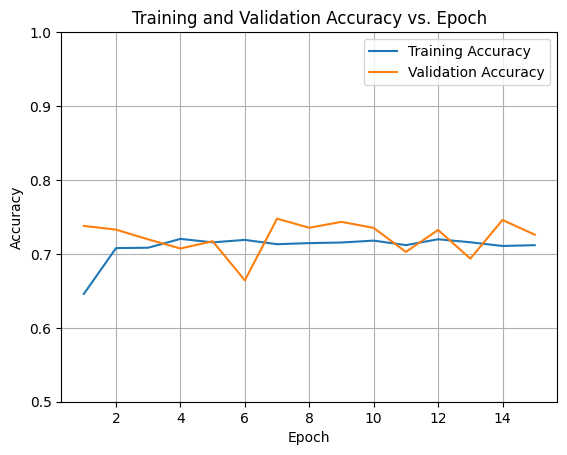

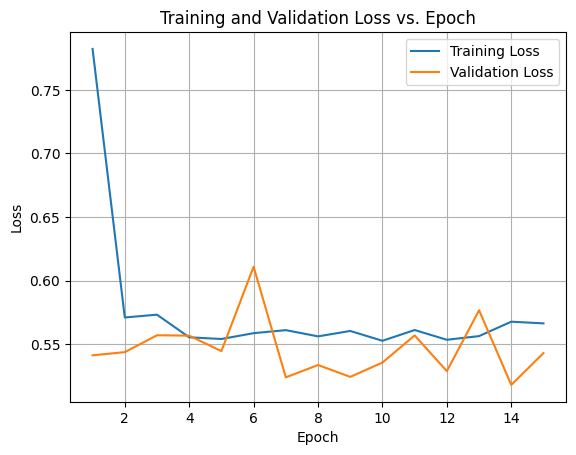

In [ ]:
# prompt: plotting training and validation accuracies using matplot

# Plotting the training and validation accuracies
#plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy vs. Epoch')
plt.legend()
plt.grid(True)
plt.ylim(0.5, 1) # Set y-axis limits from 0.5 to 1
plt.show()

# Plotting the training and validation losses
#plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss vs. Epoch')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
max(val_accuracies)

0.7476614191193247

In [ ]:
val_accuracies

[0.7378507871321013,
 0.7328313940223591,
 0.7195984485512206,
 0.7072781200091262,
 0.7170887519963496,
 0.6641569701117955,
 0.7476614191193247,
 0.7353410905772302,
 0.7433264887063655,
 0.7351129363449692,
 0.702715035363906,
 0.7323750855578371,
 0.6935888660734657,
 0.7458361852612366,
 0.7259867670545289]

../content/drive/MyDrive/ELEG845/Mar2025/try3/36698.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/15910.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/30946.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/4712.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/33514.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/27926.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/2464.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/37866.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/4158.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/34826.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/18690.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/14152.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/3546.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/27976.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/13842.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/30270.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/31620.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/9328.j

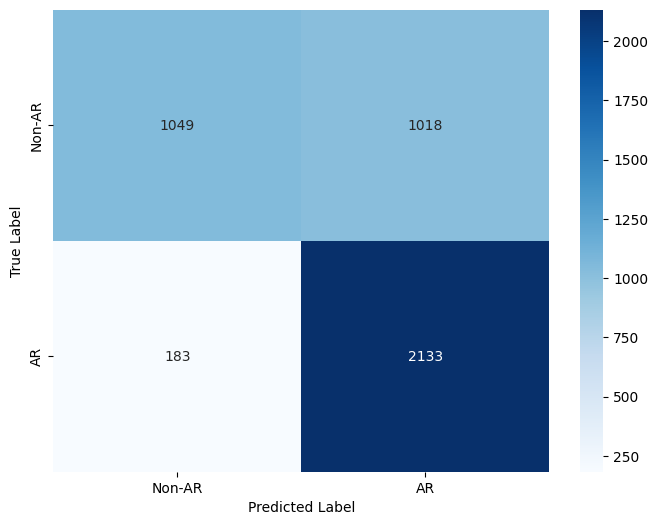

In [ ]:
# prompt: create confusion matrix for final epoch

from sklearn.metrics import confusion_matrix

# Get the true labels and predictions for the validation set
all_labels = []
all_predictions = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device=device)
        labels = labels.to(device=device)

        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Define class names (assuming 0 and 1 based on the context)
class_names = ['Non-AR', 'AR']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
#plt.title('Confusion Matrix for Final Epoch')
plt.show()